In [104]:
from ipyleaflet import Map, TileLayer, basemaps, GeoJSON
from ipywidgets import interact, IntSlider, Dropdown, FloatRangeSlider, VBox, HBox, HTML
import requests
import json
import numpy as np
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import time
#import shared

# Configuration
TILE_SERVER_URL = "http://localhost:5000"

print("✓ Imports loaded")
print(f"Testing tile server at: {TILE_SERVER_URL}")

✓ Imports loaded
Testing tile server at: http://localhost:5000


## Check Tile Server Health

In [105]:
def check_server_health():
    """Check if tile server is running"""
    try:
        response = requests.get(f"{TILE_SERVER_URL}/health", timeout=5)
        if response.status_code == 200:
            data = response.json()
            print("✓ Tile server is RUNNING")
            print(f"  Pyramids loaded: {data['pyramids_loaded']}")
            print(f"  Tiles cached: {data['tiles_cached']}")
            return True
        else:
            print("✗ Server responded with error:", response.status_code)
            return False
    except requests.exceptions.ConnectionError:
        print("✗ Cannot connect to tile server!")
        print("  Make sure to run: python tile_server_pyramid.py")
        return False
    except Exception as e:
        print(f"✗ Error: {e}")
        return False

# Run health check
check_server_health()

✓ Tile server is RUNNING
  Pyramids loaded: 0
  Tiles cached: 0


True

## Inspect Pyramid Information

In [120]:
def get_pyramid_info(variable, profile=0):
    """Get pyramid metadata"""
    try:
        response = requests.get(
            f"{TILE_SERVER_URL}/pyramid/info/{variable}",
            params={'profile': profile}
        )
        
        if response.status_code == 200:
            return response.json()
        else:
            print(f"Error: {response.status_code}")
            print(response.text)
            return None
    except Exception as e:
        print(f"Error: {e}")
        return None

# Test with Rainf_tavg
variable = 'Rainf_tavg'
info = get_pyramid_info(variable)

if info:
    print(f"✓ Pyramid info for {variable}:")
    print(f"  Zoom levels: {info['zoom_levels']}")
    print(f"  Data bounds: {info['data_bounds']}")
    print(f"\n  Level details:")
    for zoom, details in info['levels'].items():
        print(f"    Zoom {zoom}: {details['shape']} grid, grain={details['grain']}")

✓ Pyramid info for Rainf_tavg:
  Zoom levels: [0, 1, 2, 3, 4, 5]
  Data bounds: {'lat_max': 5.975, 'lat_min': -20.975, 'lon_max': -49.025, 'lon_min': -81.975}

  Level details:
    Zoom 0: [18, 22] grid, grain=30
    Zoom 1: [36, 44] grid, grain=15
    Zoom 2: [54, 66] grid, grain=10
    Zoom 3: [135, 165] grid, grain=4
    Zoom 4: [270, 330] grid, grain=2
    Zoom 5: [540, 660] grid, grain=1


## Test Single Tile Generation

Testing tile generation...
Url: http://localhost:5000/tiles/Rainf_tavg/0/0/2/2/1.png
✓ Tile fetched in 2.204s
  Size: (256, 256), Mode: RGBA


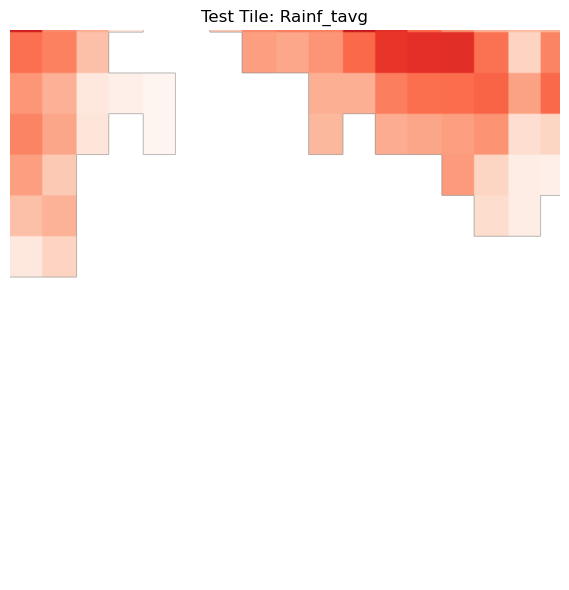

In [134]:
def fetch_tile(variable, 
               time_idx=0, 
               category=0, 
               zoom=3, x=2, y=1, 
               colormap='Reds', 
               vmin=None, vmax=None, 
               profile=0):
    """Fetch a single tile from the server"""
    
    url = f"{TILE_SERVER_URL}/tiles/{variable}/{time_idx}/{category}/{zoom}/{x}/{y}.png"
    print(f'Url: {url}')
    params = {
        'colormap': colormap,
        'profile': profile
    }
    if vmin is not None:
        params['vmin'] = vmin
    if vmax is not None:
        params['vmax'] = vmax
    
    start = time.time()
    response = requests.get(url, params=params)
    elapsed = time.time() - start
    
    if response.status_code == 200:
        img = Image.open(BytesIO(response.content))
        print(f"✓ Tile fetched in {elapsed:.3f}s")
        print(f"  Size: {img.size}, Mode: {img.mode}")
        return img
    else:
        print(f"✗ Error {response.status_code}: {response.text}")
        return None

# Test tile generation
print("Testing tile generation...")
tile = fetch_tile('Rainf_tavg', time_idx=0, category=0, 
                  zoom=2, x=2, y=1, vmin=40, vmax=100)

if tile:
    plt.figure(figsize=(6, 6))
    plt.imshow(tile)
    plt.title('Test Tile: Rainf_tavg')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # plt.figure(figsize=(10, 8))
    # plt.pcolormesh(tile)
    # #plt.colorbar(label='Value')
    # plt.title('Tile at Zoom=2, X=2, Y=1')
    # # plt.xlabel('Longitude')
    # # plt.ylabel('Latitude')
    # plt.show()

## Performance Test - Multiple Tiles

In [ ]:
def benchmark_tiles(variable, time_idx=0, category=2, zoom=3, n_tiles=9):
    """Benchmark tile generation performance"""
    
    print(f"Benchmarking {n_tiles} tiles at zoom {zoom}...")
    
    times = []
    for i in range(n_tiles):
        x = i % 3
        y = i // 3
        
        url = f"{TILE_SERVER_URL}/tiles/{variable}/{time_idx}/{category}/{zoom}/{x}/{y}.png"
        
        start = time.time()
        response = requests.get(url, params={'cache': 'false'})  # Disable cache for fair test
        elapsed = time.time() - start
        
        if response.status_code == 200:
            times.append(elapsed)
            print(f"  Tile ({x},{y}): {elapsed:.3f}s")
        else:
            print(f"  Tile ({x},{y}): ERROR {response.status_code}")
    
    if times:
        print(f"\n✓ Performance Summary:")
        print(f"  Average: {np.mean(times):.3f}s")
        print(f"  Min: {np.min(times):.3f}s")
        print(f"  Max: {np.max(times):.3f}s")
        print(f"  Total: {np.sum(times):.3f}s")

# Run benchmark
benchmark_tiles('Rainf_tavg', zoom=3, n_tiles=9)

## Test ipyleaflet

In [ ]:
def create_test_map(variable='Rainf_tavg', time_idx=0, category=2, profile=0):
    """Create an interactive ipyleaflet map with tile layer"""
    
    # Create base map
    m = Map(
        center=(-7.5, -65.5),  # Amazon center
        zoom=5,
        scroll_wheel_zoom=True,
        basemap=basemaps.Esri.WorldImagery
    )
    
    # Build tile URL
    tile_url = (
        f"{TILE_SERVER_URL}/tiles/{variable}/{time_idx}/{category}/"
        f"{{z}}/{{x}}/{{y}}.png?colormap=Reds&profile={profile}"
    )
    
    # Add data layer
    data_layer = TileLayer(
        url=tile_url,
        name=variable,
        opacity=0.7,
        attribution='HydroViewer',
        tms=True  # Server uses TMS coordinates (Y=0 at south)
        # bounds = [(-81.975, -20.975), (-49.025, 5.975)]
    )
    m.add_layer(data_layer)
    
    # Add HydroBasins polygons
    # try:
    #     import urllib.request
    #     with urllib.request.urlopen(shared.hydrobasins_lev05_url) as url:
    #         geojson_data = json.loads(url.read().decode())
        
    #     polygon_layer = GeoJSON(
    #         data=geojson_data,
    #         style={
    #             'color': 'white',
    #             'weight': 1.5,
    #             'fillOpacity': 0,
    #             'opacity': 1
    #         },
    #         hover_style={
    #             'color': 'yellow',
    #             'weight': 3
    #         }
    #     )
    #     m.add_layer(polygon_layer)
    #     print("✓ HydroBasins loaded")
    # except Exception as e:
    #     print(f"⚠ Could not load HydroBasins: {e}")
    
    return m

# Create map
print("Creating interactive map...")
test_map = create_test_map()
test_map